In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
# 1 O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
# Igual fizemos no início do módulo atual no início da primeira aula.

In [64]:
df = pd.read_csv('C:/Users/user/Documents/EBAC/dados/CHURN_TELECON_MOD08_TAREFA_TRATADOS.csv') # Abrindo o novo DataFrame

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,Servico_Telefone,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,False,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.850000,29.85,No
1,5575-GNVDE,Male,False,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.950000,1889.50,No
2,3668-QPYBK,Male,False,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.850000,108.15,Yes
3,7795-CFOCW,Male,False,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),65.607563,1840.75,No
4,8191-XWSZG,Female,False,No,No,52,Yes,No,No,No,No,One year,Mailed check,65.607563,1022.95,No
5,9959-WOFKT,Male,False,No,Yes,71,Yes,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),65.607563,7382.25,No
6,4190-MFLUW,Female,False,Yes,Yes,10,Yes,DSL,No,Yes,No,Month-to-month,Credit card (automatic),65.607563,528.35,Yes
7,4183-MYFRB,Female,False,No,No,21,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,65.607563,1862.90,No
8,8779-QRDMV,Male,True,No,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,65.607563,39.65,Yes
9,1680-VDCWW,Male,False,Yes,No,12,Yes,No,No,No,No,One year,Bank transfer (automatic),65.607563,202.25,No


In [ ]:
# 2) Comece pela análise univariada:

In [ ]:
# A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

In [6]:
df.describe() # exibe o panorama das nossas variáveis quantitativas (numéricas)

,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2488.000000,2488.000000,2488.000000
mean,32.352090,65.607563,2290.087178
std,24.636885,27.984700,2264.585643
min,0.000000,18.400000,18.800000
25%,8.000000,45.400000,402.337500
50%,29.000000,65.607563,1402.900000
75%,56.000000,87.712500,3867.162500
max,72.000000,118.650000,8564.750000


In [ ]:
# B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

In [ ]:
# é possível ver que não existe forte presença de outliers pois os dados estão bem distribuidos

In [ ]:
# C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

In [22]:
(df['Tempo_como_Cliente'] == 0).sum()

5

In [12]:
(df['Tempo_como_Cliente'] == 0).mean() * 100

0.20096463022508038

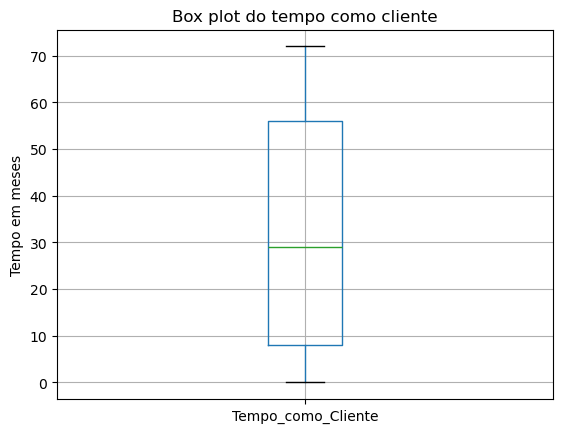

In [65]:
df.boxplot(column='Tempo_como_Cliente')
plt.title('Box plot do tempo como cliente')
plt.ylabel('Tempo em meses')
plt.show()

In [28]:
(df['Pagamento_Mensal'] == 0).sum()

0

In [29]:
(df['Pagamento_Mensal'] == 0).mean() * 100

0.0

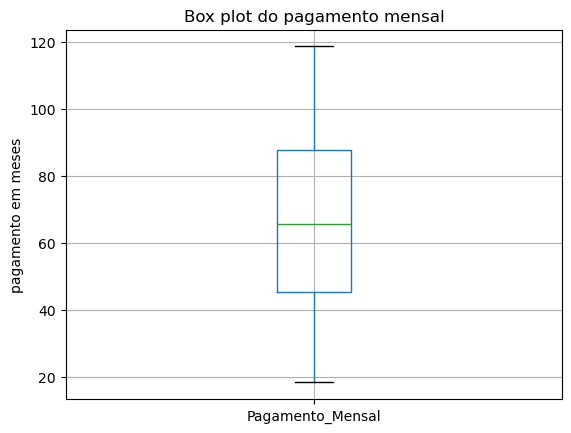

In [30]:
df.boxplot(column='Pagamento_Mensal')
plt.title('Box plot do pagamento mensal')
plt.ylabel('pagamento em meses')
plt.show()

In [31]:
(df['Total_Pago'] == 0).sum()

0

In [32]:
(df['Total_Pago'] == 0).mean() * 100

0.0

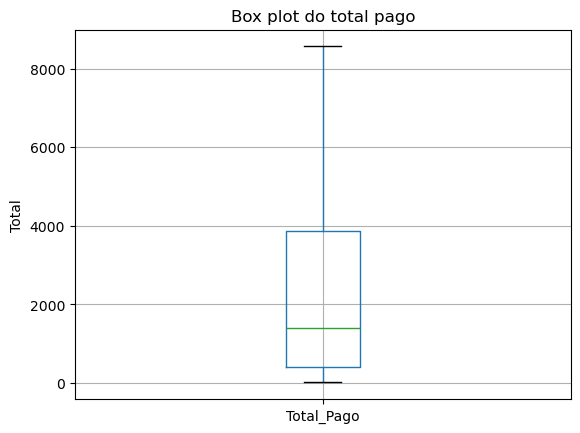

In [33]:
df.boxplot(column='Total_Pago')
plt.title('Box plot do total pago')
plt.ylabel('Total')
plt.show()

In [ ]:
# D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

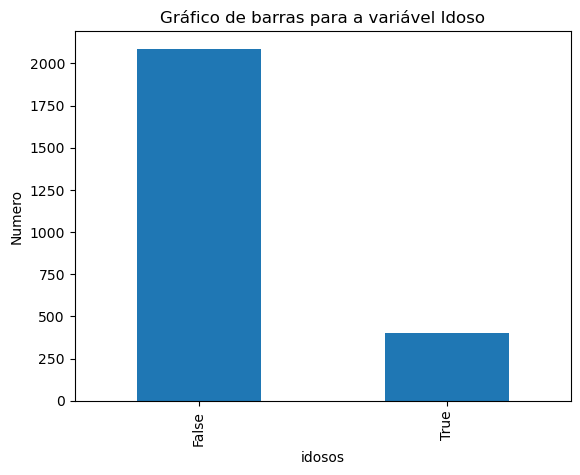

In [46]:
# Contagem dos valores da coluna Idoso

contagem_Idoso = df['Idoso'].value_counts()

# Calculando a porcentagem para que apareça no grafico

porcentagem_Idoso = (contagem_Idoso / contagem_Idoso.sum()) * 100
ax = contagem_Idoso.plot(kind='bar')
plt.title('Gráfico de barras para a variável Idoso')
plt.xlabel('idosos')
plt.ylabel('Numero')
plt.show()

In [48]:
# Calculando a quantidade das ocorrencias

contagem_idoso = df['Idoso'].value_counts()

# Porcentagem 

(contagem_idoso / contagem_idoso.sum()) * 100

Idoso
False    83.842444
True     16.157556
Name: count, dtype: float64

In [51]:
# O FALSE (Falso idoso ou nao idoso) representa mais de 83% dos clientes e isto demonstra dificuldade para criar modelos preditivos para a categoria "nao idoso" no futuro por ser uma base de dados pequena.

In [50]:
# 3) Identifique e trate as colunas que contém outliers.
# Caso opte por mante-los ou altera-los justifique sua escolha.


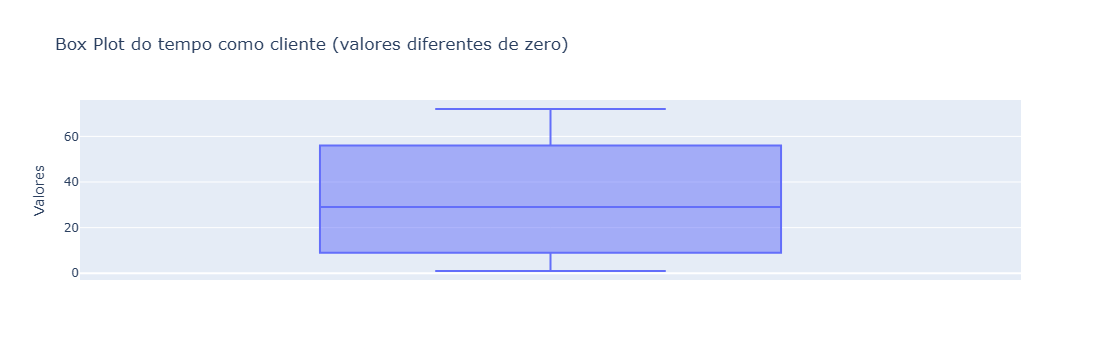

In [66]:
df_nao_zero = df[df['Tempo_como_Cliente'] != 0]

fig = px.box(df_nao_zero, y='Tempo_como_Cliente', title='Box Plot do tempo como cliente (valores diferentes de zero)', labels ={'Tempo_como_Cliente': 'Valores'})
fig.show()

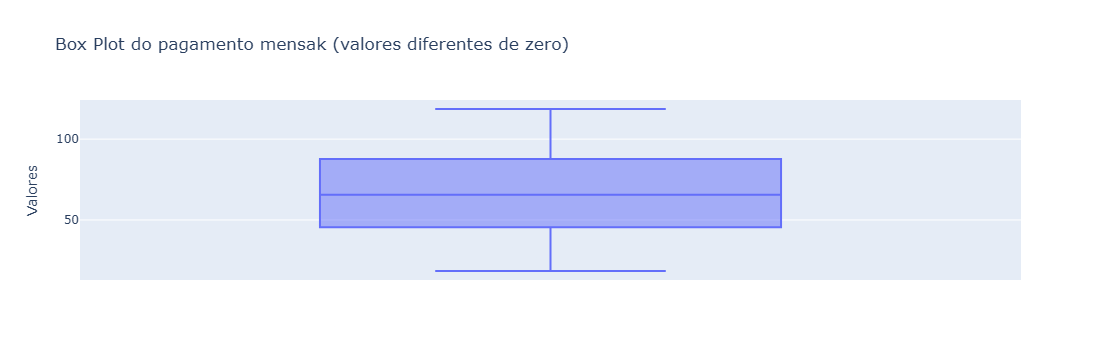

In [67]:
df_nao_zero = df[df['Pagamento_Mensal'] != 0]

fig = px.box(df_nao_zero, y='Pagamento_Mensal', title='Box Plot do pagamento mensak (valores diferentes de zero)', labels ={'Pagamento_Mensal': 'Valores'})
fig.show()

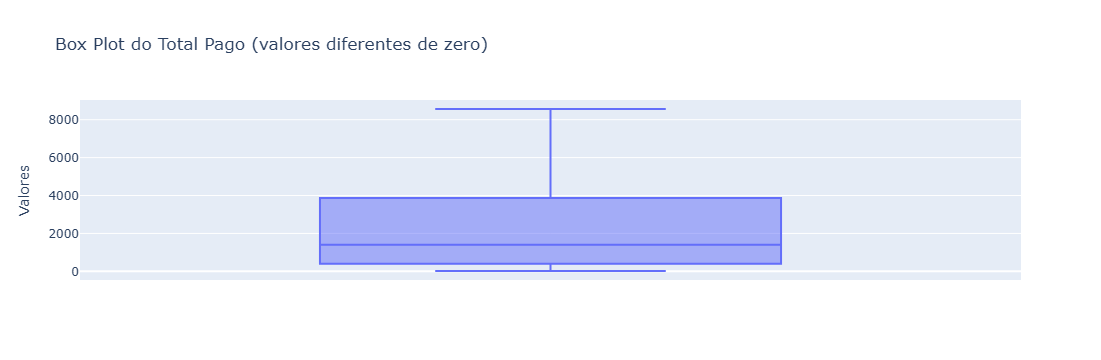

In [68]:
df_nao_zero = df[df['Total_Pago'] != 0]

fig = px.box(df_nao_zero, y='Total_Pago', title='Box Plot do Total Pago (valores diferentes de zero)', labels ={'Total_Pago': 'Valores'})
fig.show()

In [ ]:
# Como demonstrado nos plots anteriores, Não identifiquei presença de Outliers no dataset fornecido 

In [ ]:
# 4) Realize a etapa da análise bivariada:

In [ ]:
# A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.

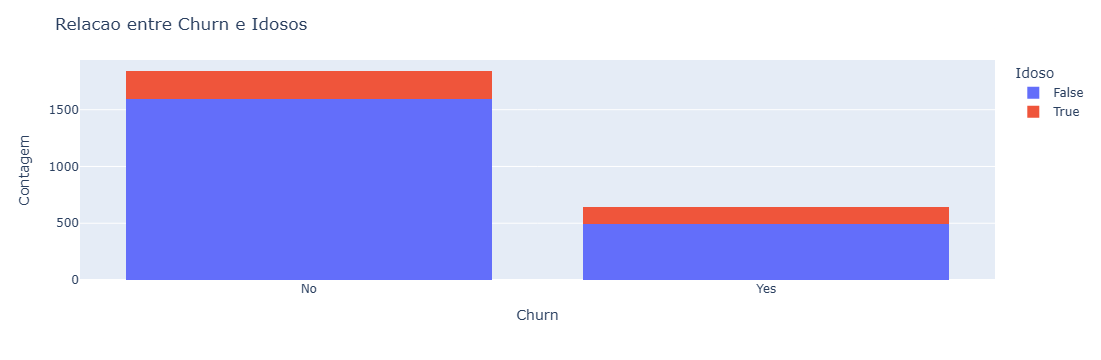

In [70]:
# Churn x idoso

fig = px.histogram(df, x='Churn', color='Idoso', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Churn e Idosos',
		  xaxis_title='Churn',
		  yaxis_title='Contagem',
		  legend_title='Idoso')
fig.show()

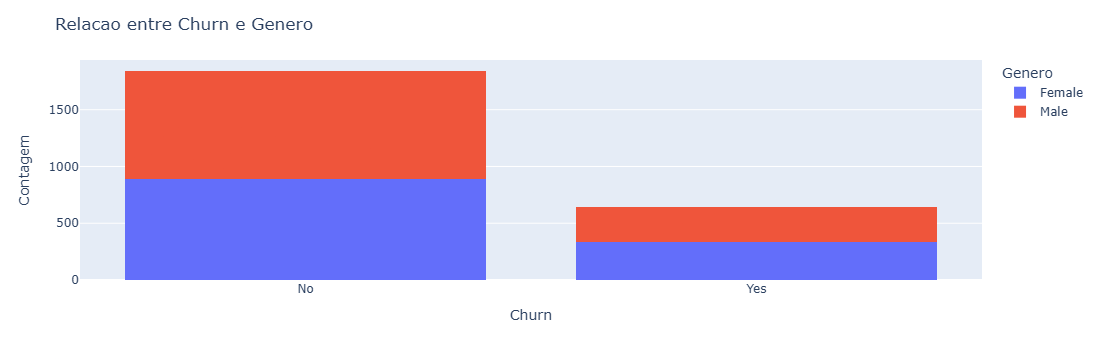

In [71]:
# Churn x Genero

fig = px.histogram(df, x='Churn', color='Genero', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Churn e Genero',
		  xaxis_title='Churn',
		  yaxis_title='Contagem',
		  legend_title='Genero')
fig.show()

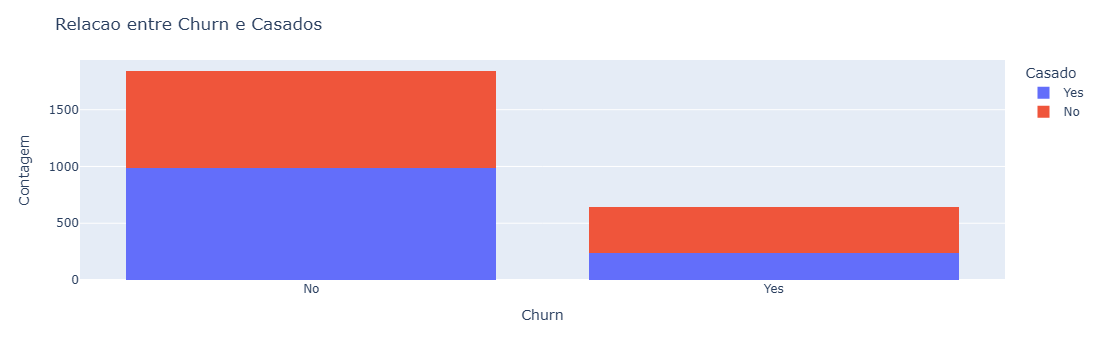

In [72]:
# Churn x Casado

fig = px.histogram(df, x='Churn', color='Casado', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Churn e Casados',
		  xaxis_title='Churn',
		  yaxis_title='Contagem',
		  legend_title='Casado')
fig.show()

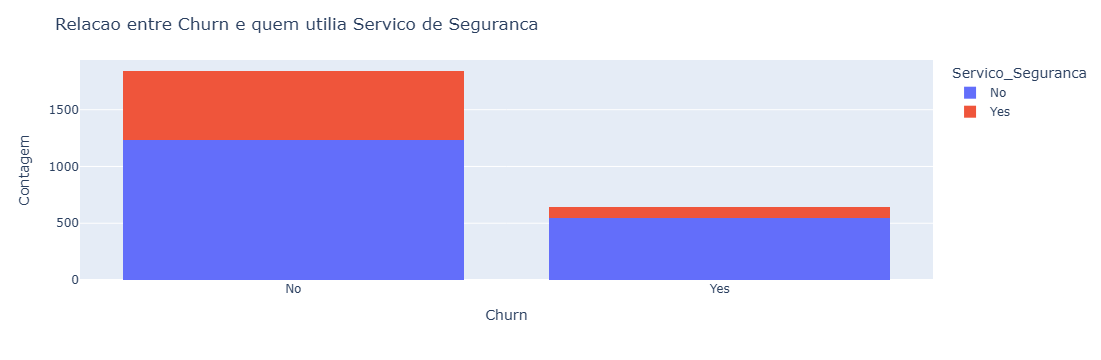

In [74]:
# Churn x servico telefone

fig = px.histogram(df, x='Churn', color='Servico_Seguranca', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Churn e quem utilia Servico de Seguranca',
		  xaxis_title='Churn',
		  yaxis_title='Contagem',
		  legend_title='Servico_Seguranca')
fig.show()

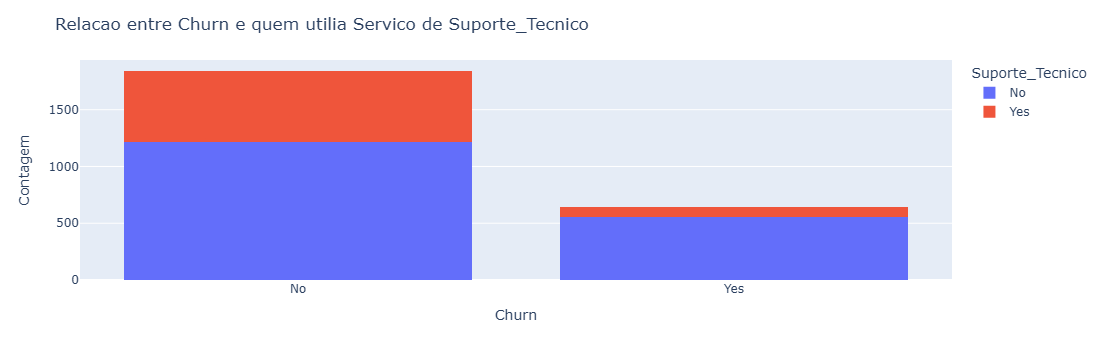

In [76]:
# Churn x Suporte_Tecnico

fig = px.histogram(df, x='Churn', color='Suporte_Tecnico', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Churn e quem utilia Servico de Suporte_Tecnico',
		  xaxis_title='Churn',
		  yaxis_title='Contagem',
		  legend_title='Suporte_Tecnico')
fig.show()

In [ ]:
# os idosos sao grande maioria dos usuarios e, sao mais propensos ao churn em questao de proporcao

# existe um equilibrio em churn entre homens e mulheres

# percebemos tambem que os solteiros sao mais propensos ao churn

# Dentre os usuarios que utilizam o servico de seguranca poucos optam por dar um churn

# é possivel afirmar que pouquissimas pessoas que utiliam do suporte tecnico acabam por dar churn

In [ ]:
# B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

In [ ]:
# idoso, genero, casados, servico_seguranca e suporte_tecnico.

# questoes familiares sempre sao muito relevantes pelo fato de ter que agradar um grupo e seguranca e suporte sao essenciais para o cliente sentir-se acolhido e bem tratado pela empresa